In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df=pd.read_csv("data.csv")
print(df.head())
print(df.shape)
print(df.dtypes)

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [3]:
#checking if any of the columns have null values
print(df.isnull().sum())
print(df)

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
        UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0         1     M14860    M                298.1                    308.6   
1         2     L47181    L                298.2                    308.7   
2         3     L47182    L                298.1                    308.5   
3         4     L47183    L                298.2                    308.6   
4         5     L47184    L                298.2                    308.7   
...     ...        ...  ...                  ...                      ...   
9995   9996     M24855    M               

In [4]:
#checking by adding if there are na values
print(df.isna().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


df=df.drop(columns=['UDI',                        0
'Product ID'])

In [5]:
#dropping un necessary columns
df=df.drop(columns=['UDI',                      
'Product ID'])
print(df.head())

  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0                9                0    0    0    0    0    0  


In [6]:
print(df)

     Type  Air temperature [K]  Process temperature [K]  \
0       M                298.1                    308.6   
1       L                298.2                    308.7   
2       L                298.1                    308.5   
3       L                298.2                    308.6   
4       L                298.2                    308.7   
...   ...                  ...                      ...   
9995    M                298.8                    308.4   
9996    H                298.9                    308.4   
9997    M                299.0                    308.6   
9998    H                299.0                    308.7   
9999    M                299.0                    308.7   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  \
0                       1551         42.8                0                0   
1                       1408         46.3                3                0   
2                       1498         49.4             

In [7]:
#counting the number of failure machines
print(df.value_counts('Machine failure'))

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [8]:
print(df.head())

  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0                9                0    0    0    0    0    0  


In [9]:
#comparing machine failure and air temperature
pd.crosstab(df['Machine failure'],df['Air temperature [K]'])

Air temperature [K],295.3,295.4,295.5,295.6,295.7,295.8,295.9,296.0,296.1,296.2,...,303.6,303.7,303.8,303.9,304.0,304.1,304.2,304.3,304.4,304.5
Machine failure,,,,,,,,,,,,,,,,,,,,,
0,3,3,18,37,17,18,10,6,12,26,...,73,92,72,57,43,46,40,15,6,1
1,0,0,0,1,1,1,0,0,0,0,...,5,4,3,1,2,0,0,0,1,0


In [10]:
#calculating temperature difference
df['temperature difference']=df['Process temperature [K]']-df['Air temperature [K]']
print(df['temperature difference'])

0       10.5
1       10.5
2       10.4
3       10.4
4       10.5
        ... 
9995     9.6
9996     9.5
9997     9.6
9998     9.7
9999     9.7
Name: temperature difference, Length: 10000, dtype: float64


In [11]:
#comparing machine failure and temperature difference
pd.crosstab(df['Machine failure'],df['temperature difference'])

temperature difference,7.6,7.6,7.7,7.7,7.8,7.8,7.9,7.9,8.0,8.1,...,11.6,11.7,11.7,11.8,11.8,11.9,11.9,12.0,12.1,12.1
Machine failure,,,,,,,,,,,,,,,,,,,,,
0,5,1,17,17,11,62,36,15,48,23,...,55,34,18,9,36,35,15,28,2,2
1,2,0,4,2,2,11,4,5,7,3,...,0,0,0,0,0,0,1,1,0,0


In [12]:
#checking if toolwear group effects the machine failure
df['tool_wear_group'] = pd.cut(df['Tool wear [min]'], 
                                bins=3, 
                                labels=['Low', 'Medium', 'High'])
print(pd.crosstab(df['tool_wear_group'], df['Machine failure'],
                  normalize='index') * 100)

Machine failure          0         1
tool_wear_group                     
Low              97.843187  2.156813
Medium           97.701750  2.298250
High             92.556054  7.443946


In [13]:
#checking if torque group effects the machine failure
df['torque_group']=pd.cut(df['Torque [Nm]'],bins=3,labels=['Low','Medium','High'])
print(pd.crosstab(df['torque_group'],df['Machine failure'],normalize='index')*100)

Machine failure          0          1
torque_group                         
Low              96.629213   3.370787
Medium           98.549050   1.450950
High             82.274882  17.725118


In [14]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature difference,tool_wear_group,torque_group
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,Low,Medium
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,Low,Medium
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,Low,Medium
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,Low,Medium
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,Low,Medium


In [15]:
#calcualting power and high_wear_risk for feature engineering
df['power']=df['Torque [Nm]']*df['Rotational speed [rpm]']
df['high_wear_risk'] = (df['Tool wear [min]'] >= 200).astype(int)
print(df['power'])
print(df['high_wear_risk'])

0       66382.8
1       65190.4
2       74001.2
3       56603.5
4       56320.0
         ...   
9995    47318.0
9996    51897.6
9997    54943.0
9998    68288.0
9999    60300.0
Name: power, Length: 10000, dtype: float64
0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: high_wear_risk, Length: 10000, dtype: int64


In [16]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature difference,tool_wear_group,torque_group,power,high_wear_risk
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,Low,Medium,66382.8,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,Low,Medium,65190.4,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,Low,Medium,74001.2,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,Low,Medium,56603.5,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,Low,Medium,56320.0,0


In [17]:
#comparing power and high wear risk to machine failure
df[['power','high_wear_risk','Machine failure']]
print(pd.crosstab(df['high_wear_risk'],df['Machine failure']))

Machine failure     0    1
high_wear_risk            
0                8983  216
1                 678  123


In [18]:
df.to_csv('maintenance_cleaned.csv', index=False)
print("Saved! ✅")

Saved! ✅


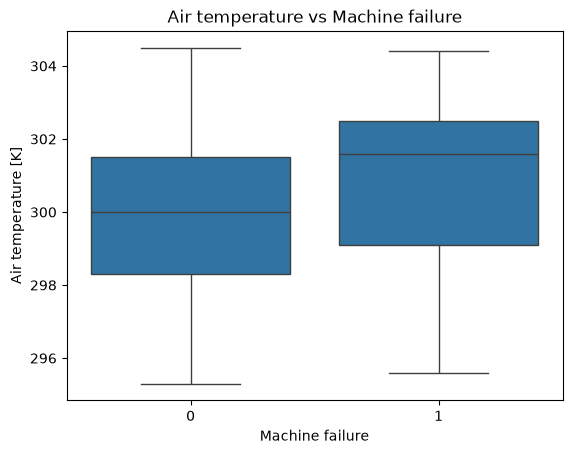

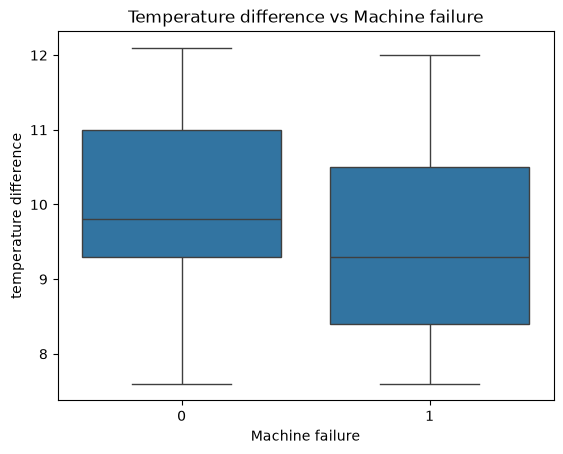

In [19]:
import matplotlib.pyplot as plt
import seaborn as sb

# Boxplot: air temperature distribution for failure vs no failure
sb.boxplot(x='Machine failure', y='Air temperature [K]', data=df)
plt.title('Air temperature vs Machine failure')
plt.show()

# Boxplot: temperature difference
sb.boxplot(x='Machine failure', y='temperature difference', data=df)
plt.title('Temperature difference vs Machine failure')
plt.show()

In [21]:
# Bin air temperature
df['air_temp_group'] = pd.cut(df['Air temperature [K]'],
                              bins=3,
                              labels=['Low', 'Medium', 'High'])

# Now crosstab — same cell, guaranteed to exist
print(pd.crosstab(df['air_temp_group'], df['Machine failure'],
                  normalize='index') * 100)

Machine failure          0         1
air_temp_group                      
Low              97.895155  2.104845
Medium           97.730061  2.269939
High             93.248457  6.751543
